<b>Group Number:</b>  8
<br><b>Name Group Member 1:</b>  Arne Segatz
<br><b>u-Kürzel Group Member 1:</b>  urnye
<br><b>Name Group Member 2:</b> Anton Seifert 
<br><b>u-Kürzel Group Member 2:</b> unjud 

# Task 7.1: Natural Language Processing with LSTMs and Transformer

## Basics

In the following, you'll a brief introduction and explanation into recurrent neural networks. This is split up into vanilla recurrent neural networks and long short-term memory recurrent neural networks. This will include  

### Recurrent Neural Networks (RNNs)

By now, you should have learned the basics of feedforward neural networks (FNN). One disadvantage of FNNs is that they struggle to learn relationships between multiple samples. They do not retain information about previous inputs and cannot establish connections between them. This limitation is significant when dealing with sequential data, such as time series data. Prominent examples include weather data or stock prices, where the order of the data is crucial for predicting patterns. This is where a new group of neural networks come into the play: Recurrent Neural Networks (RNNs).

The basic vanilla RNN, in the following simply RNN named, was first introduced in the 1980s [[1]](#1)[[2]](#2). It was later replaced by Long short-term memory (LSTM) RNNs and Gated Recurrent Units (GRU). Therefore, RNNs are nowadays outdated. However, it is important to thoroughly understand them before moving on to the more complex models. 

Consequently, in the following you will find an introduction to RNNs before we move on to LSTMs. GRUs will not be content of this notebook. 

#### Vanilla RNN
##### Structure

The main difference to the classic FNN is, that the hidden layer of a RNN has a connection to itself (fig. 1 [[3]](#3)). 

<p align="center">
  <img src="images/rnn_overview.png" width="60%" height="auto"/>
  <br>
  <em>Figure 1: Neural network and Recurrent neural network cell.</em>
</p>

The different hidden states are connected via the weight matrix $\mathbf{W_{hh}}$, such that the information from the samples before are fed back into the network. We can also unroll this network (fig. 2) hypothetically, to better understand its structure.

<p align="center">
  <img src="images/rnn_unrolled.png" width="70%" height="auto"/>
  <br>
  <em>Figure 2: An unrolled Recurrent Neural Network.</em>
</p>

Each $\mathbf{X^{<1>}}, \mathbf{X^{<2>}}, \dots, \mathbf{X^{<t>}}$ represents one sample, consisting of $K$ features. $t$ is the so-called sequence length, e.g., the number of days to process sequentially in weather forecasting before making a prediction. Each step of the sequence length has a corresponding RNN cell. For example, in case we have a sequence length of three steps, that woudl result in 3 RNN cells.

Using the matrix $\mathbf{W_{xh}}$, every sample is transformed into a hidden state. The hidden state is then transformed into the outputs $\mathbf{O^{<1>}} \dots \mathbf{O^{<t>}}$. This results in the following RNN equations [[3]](#3):

$$\mathbf{H^{<t>}}=g_1(\mathbf{W_{xh}}\mathbf{X^{<t>}}+\mathbf{W_{hh}}\mathbf{H^{<t-1>}}+\mathbf{b_h}) \newline
\mathbf{O^{<t>}} = g_2(\mathbf{W_{ho}}\mathbf{H^{<t>}}+\mathbf{b_o})$$

$\mathbf{b_h}$ and $\mathbf{b_o}$ are the biases, and $g_1$ and $g_2$ are the activation functions. From the first equation, you can see that each hidden state $\mathbf{H^{<t>}}$ recursively contains information from former states $\mathbf{H^{<t-1>}}\dots \mathbf{H^{<0>}}$. $\mathbf{H^{<0>}}$ usually consists of zeros [[4]](#4). 

Overall, there exist only these three weight matrixes $\mathbf{W_{xh}}$, $\mathbf{W_{hh}}$ and $\mathbf{W_{ho}}$ per one RNN layer.

##### Dimensions

Now, let's examine the dimensions of each component. Keep in mind, that the order of the dimensions can vary. In case that they don't match, transposition is necessary. The order is also dependent on the chosen ML library.

The input has three dimensions:
1. **Batch size $B$:** This represents the number of sequences processed, before making a backwards pass. 
2. **Sequence length $t$:** This indicates the number of time steps processed at once (sequence length), such as the number of days in weather forecasting or the number of words in a sentence for predicting the next likely word. Usually, each sample/ step is one row in a csv, dataframe, array or whatever. 
3. **Number of features $K$:** This is equivalent to the columns of your data structure.

This results in a tensor of shape $\text{Input}\in \mathbb{R}^{B\times t \times K}$.

In the following, we are ignoring the batch size dimension and only care about the sequence length $t$ and the features $K$.

The weight matrix $\mathbf{W_{xh}}$ has to fit to the $K$ features of the input sample $\mathbf{X^{<t>}} \in \mathbb{R}^{1\times K}$. Questionable is the size of the second dimension of $\mathbf{W_{xh}}$. It has to match the size of the hidden state $\mathbf{H^{<t>}}\in \mathbb{R}^{1\times h}$, which is the equivalent to the number of neurons $h$ of a hidden FNN layer. In Keras, we set this size with the <code>unit</code> argument. In Pytorch it is <code>hidden_size</code>. Therefore, we can keep in mind: $$\mathbf{W_{xh}} \in \mathbb{R}^{K\times h}$$ **Do not confuse the unit size/ hidden size with the number of RNN cells.** The unit size/ hidden size is chosen by us and determines the capability of our model. The number of cells is solely dependent on the number of steps $t$ in one sequence that we process. 

Obviously, the sizes of the weight matrix is $\mathbf{W_{hh}} \in \mathbb{R}^{h\times h}$. Otherwise, the hidden states would not fit together. The biase shape is $\mathbf{b_h} \in \mathbb{R}^{1\times h}$. 

The remaining matrix $\mathbf{W_{oh}}$ transforms the hidden state into the output. However, in Keras and Pytorch, this is missing. In both cases, the hidden state is directly brought to the output. 

In Keras, we have the argument <code>return_sequences</code>. If <code>True</code>, than we receive every output state $\mathbf{O^{<1>}}, \mathbf{O^{<1>}} \dots \mathbf{O^{<t>}} = \mathbf{O_t}$. Else, only the last output $\mathbf{O^{<t>}}$. In Pytorch, we always get the complete sequence of outputs. If we are only interested in the last output, we have to slice the tensor. Upon the last RNN layer is often a FNN stacked, e.g. for classification tasks. This helps in adjusting the output dimension as well. 

##### Training

The training process for RNNs is analogous to that of FNNs. The algorithm used is known as Backpropagation Through Time (BPTT). During BPTT, the loss function is differentiated with respect to the weight matrices $\mathbf{W_{xh}}$, $\mathbf{W_{hh}}$, and $\mathbf{W_{oh}}$ [[3]](#3). A detailed exploration of this algorithm is beyond the scope of this discussion.

##### Usage

RNNs can be used for different tasks. A great overview is depicted in figure 3 [[6]](#6).

<p align="center">
  <img src="images/rnn_tasks.png" width="50%" height="auto"/>
  <br>
  <em>Figure 3: Different RNN applications.</em>
</p>

##### Problems

RNNs have fallen out of favor quite some time ago primarily due to their susceptibility to the vanishing and exploding gradient problem. This issue arises during the backpropagation process, where derivatives of the hidden states are repeatedly multiplied. If the values are small (less than 1), the gradients can diminish exponentially, eventually vanishing after several steps. As a result, weight updates become negligible, hindering learning. Conversely, if the values are large (greater than 1), the gradients can grow exponentially, leading to exploding gradients. This causes excessively large weight updates, resulting in oscillations and instability in the training process [[3]](#3).

In 1997 a new type of machine learning model was proposed to much improve on these problems: Long short-term Memory RNNs (LSTM) [[4]](#4). They are able to learn over a lot more steps (way over 1000).


#### LSTM

A LSTM cell (fig. 4  [[7]](#7)) consists of a cell state and a hidden state. The hidden state can be understood as working memory. It is very similar to the hidden state of the RNN. Different to that is the cell state. It is used by the model to store long term valuable information that it might not need immediately. 

To summarize:
- The hidden state primarily represents the latest time-steps.
- The cell state essentially serves as the global or cumulative memory of the LSTM network across all time-steps.

<p align="center">
  <img src="images/lstm_cell_overview.png" width="50%" height="auto"/>
  <br>
  <em>Figure 4: Overview over a LSTM cell.</em>
</p>

Hidden state and cell state are connected via the forget gate, input gate and output gate. Those are used to diminish or amplify some information and are basically separate FNNs. In the following, we will go over each gate shortly and describe its purpose in more detail. 

##### Forget Gate

The forget gate, as the name implies, manages whether the information stored from $\mathbf{c_{t-1}}$ should be retained or not. This is done via a FNN that takes the input $\mathbf{x_t}$ and the hidden state $\mathbf{h_{t-1}}$ and outputs a value between $0$ (forget the cell state $\mathbf{c_{t-1}}$) and $1$ (keep the cell state). The equation for the forget gates output is

$$\mathbf{f_t} = \sigma(\mathbf{W_{hf}}\mathbf{h_{t-1}}+\mathbf{W_{xf}\mathbf{x_t}}+\mathbf{b_f})$$

whereas $\sigma$ is often the sigmoid activation function.

To summarize, during the training process, the forget gate learns to compare the incoming information $\mathbf{x_t}$ and the recently seen information $\mathbf{h_{t-1}}$ to compare with the long term information $\mathbf{c_{t-1}}$ and can decide what is valuable and what is not [[7]](#7).

##### Input Gate

After determining the extent to which the information in $\mathbf{c_{t-1}}$ should be forgotten, the next step is to decide how much new information should be stored in $\mathbf{c_{t}}$. This is usually done with two different activation functions (see fig. 4).

The first is the $\tanh()$. It scales the information from the hidden state $\mathbf{h_{t-1}}$ and the input $\mathbf{x_t}$ multiplied with its respective weight matrixes to a range of $[-1, 1]$. By doing that, a feature extraction is happening. This stage is sometimes also called "candidate gate". $\tanh()$ is used here over a $\text{sigmoid}$ activation function, because the model is than able to increase **and** decrease the cell state $c_t$, which would not be possible otherwise [[8]](#8)[[3]](#3). 

$$\mathbf{\tilde{c}_t} = \tanh(\mathbf{W_{h\tilde{c}}}\mathbf{h_{t-1}}+\mathbf{W_{x\tilde{c}}}\mathbf{x_t}+\mathbf{b_c})$$


The second is a $\text{sigmoid}()$. It scales the hidden state $\mathbf{h_{t-1}}$ and $\mathbf{x_t}$ down to a range of $[0, 1]$. The decision here is, whether the information is usefull to be stored or not [[3]](#3).

$$\mathbf{i_t} = \sigma(\mathbf{W_{hi}}\mathbf{h_{t-1}}+\mathbf{W_{xi}}\mathbf{x_t}+\mathbf{b_i})$$

Both the results are point-wise multiplied to determine the value to be stored in the long term memory cell state $\mathbf{c_t}$. 

$$\mathbf{c_t} = f_t \odot \mathbf{c_{t-1}} + \mathbf{i_t} \odot \mathbf{\tilde{c}_t}$$

##### Output Gate

The output gate works similar to the input gate. Via a $\tanh()$ activation function, the cell state $\mathbf{c_t}$ is point-wise multiplied with the $\text{sigmoid}()$ scaled hidden state $\mathbf{h_{t-1}}$ and the input vector $\mathbf{x_t}$. The result creates the new output and the new hidden state $\mathbf{h_t}$.  

$$\mathbf{o_t} = \sigma(\mathbf{W_{ho}}\mathbf{h_{t-1}}+\mathbf{W_{xo}}\mathbf{x_t}+\mathbf{b_o}) \\
\mathbf{h_t} = \mathbf{o_t} \odot \tanh(\mathbf{c_t})$$

##### Dimensions

In the following section, we will examine the dimensions of the weight matrices, inputs, and outputs. It is important to note that the order of the dimensions may vary depending on the library used.

Compared to the RNNs, a LSTM network has significantly more weights. These include $\mathbf{W_{xf}}, \mathbf{W_{xi}}, \mathbf{W_{xo}}, \mathbf{W_{hf}}, \mathbf{W_{hi}}, \mathbf{W_{ho}}, \mathbf{W_{x\tilde{c}}}, \mathbf{W_{h\tilde{c}}}, \mathbf{b_f}, \mathbf{b_i}, \mathbf{b_o}, \mathbf{b_{ic}}$. This increased number of weights is independent of the sequence length or the number of LSTM cells, as all cells share the same weight matrices.

The input to both RNNs and LSTMs is a tensor of shape $\text{Input} \in \mathbb{R}^{B \times t \times K}$, where $B$ represents the batch size, $t$ denotes the sequence length, and $K$ is the number of features.

The input weight matrices for LSTM have the shape $\mathbf{W_{xf}}, \mathbf{W_{xi}}, \mathbf{W_{xo}} \in \mathbb{R}^{K \times h}$. Here, $h$ is the number of hidden units, specified by the `units` attribute in Keras or the `hidden_size` attribute in PyTorch. This is analogous to the number of neurons in a hidden layer of a FNN. Models with a greater number of neurons can learn more complex patterns but are prone to overfitting and require longer training times.

The hidden weight matrices for LSTM have the shape $\mathbf{W_{hf}}, \mathbf{W_{hi}}, \mathbf{W_{ho}} \in \mathbb{R}^{h \times h}$. This is similar to RNNs, ensuring that the dimensions of the hidden states match.

The candidate weight matrices are of the shape $\mathbf{W_{x\tilde{c}}} \in \mathbb{R}^{K \times h}, \mathbf{W_{h\tilde{c}}} \in \mathbb{R}^{h \times h}$.

All bias vectors have the shape $\mathbf{b_f}, \mathbf{b_i}, \mathbf{b_o}, \mathbf{b_{ic}} \in \mathbb{R}^{1 \times h}$.

The output is a tensor of shape $\text{Output} \in \mathbb{R}^{B \times t \times h}$. Hidden state and cell state dimension is both $\mathbf{h^{<t>}}, \mathbf{c^{<t>}} \in \mathbb{R}^{1\times h}$.  

## Todays Task

Today, we will have a look at LSTM models and transformer. We do this in the context of the Simpsons dataset. It contains the transcript of all episodes of the Simpsons. Our goal will be, to create a model, that can generate new text, based on the provided dataset.

In NLP, we usually undertake the following steps:

1. Input Text
2. Pre-Processing/ Text Normalization
3. Tokenization
4. Embedding
5. Processing/ Language Model
6. Decoding
7. Output Text

Explanations will be found in each of these tasks. 

We will start with a very naive approach, where we simply let an LSTM guess the next character, based on the previous ones. Afterwards, we try to improve it by using a word2vec model and utilizing its created embedding from it. 

Last, we utilize a pre-trained GPT2 model, that we are going to fine-tune on our task. 


Let's get started!

<p align="center">
  <img src="images/simpsons-family.png" width="30%" height="auto"/>
  <br>
</p>

## Naive LSTM Model

### Imports

In [22]:
# https://machinelearningmastery.com/text-generation-with-lstm-in-pytorch/

import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
from torch.optim import lr_scheduler
from tqdm import tqdm
import time
from tempfile import TemporaryDirectory
import os.path
from collections import Counter
import numpy as np


if torch.cuda.is_available():
    print("Training on Cuda!")
    DEVICE = torch.device("cuda")

elif torch.backends.mps.is_available():
    print("Training on MPS!")
    DEVICE = torch.device("mps")
else:
    print("Neither Cuda nor MPS found - Training on CPU")
    DEVICE = torch.device("cpu")

Neither Cuda nor MPS found - Training on CPU


### Data Loading and Preprocessing

We are first going to preprocess our corpus. That means that we are removing characters that do not occure often in English, we make everything lowercase and sort the dataframe according to its <code>id</code> column. Especially two columns are interesting for us: <code>raw_text</code> offers the transcripted text. We see here also a short description what character is talking, the sentiment etc. <code>spoken_words</code> holds only the spoken words. 

For training our models, we will use <code>raw_text</code> as we want to have a greater depth in our text generation. For analysis purpose (wordclouds) we are going to use only the <code>spoken_words</code>.

<div class="alert alert-block alert-success">
<b>Task 1:</b> Remove all non-ascii characters from our dataframe <code>df</code>. Simply delete the complete row, once you have found at least one. 

<ul>
<li><b>Hint:</b> You can for example define a function that checks whether a non-ascii character is present and use <code>apply()</code>.
</ul>

<b>Task 2:</b> Make every character in the column <code>source_col</code> lowercase. 
<ul>
<li><b>Hint:</b> You can again use <code>apply()</code>. And catch cases, where the dataype is not <code>str</code>.
</ul>
</div>

In [23]:
df = pd.read_csv("data/simpsons_script_lines.csv")
# df = df.loc[df["episode_id"]<2]

df.sort_values(by = ["id"], inplace=True, axis=0)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

# STUDENT CODE HERE (2 pts)
def is_row_clean(row):
    for item in row:
        if isinstance(item, str):

            if not all(ord(char) < 128 for char in item):
                return False
    return True

df = df[df.apply(is_row_clean, axis=1)]
df.reset_index(drop=True, inplace=True)

# STUDENT CODE until HERE

def preprocess_df(df:pd.DataFrame, source_col:str):

    # STUDENT CODE HERE (1 pts)

    df[source_col] = df[source_col].apply(lambda x: x.lower() if isinstance(x, str) else x)

    # STUDENT CODE until HERE
    df[f"cleaned_{source_col}"] = df[source_col]
    df.drop(source_col, inplace=True, axis=1)

    return df

df = preprocess_df(df, "raw_text")
df = preprocess_df(df, "spoken_words")

C:\Users\arnes\AppData\Local\Temp\ipykernel_17888\2331588181.py:1: DtypeWarning: Columns (4,5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/simpsons_script_lines.csv")


<div class="alert alert-block alert-success">
<b>Task:</b> We would like to have two dictionaries. One that maps our <code>char</code> to <code>int</code> and one that goes vice-versa, to decode the generated text later again. 
</div>

In [24]:
# get set of unique_characters
unique_chars = set()
for value in df["cleaned_raw_text"]:
    unique_chars.update(set(str(value)))

n_vocab = len(unique_chars)

unique_chars = list(unique_chars)
unique_chars.sort()

# STUDENT CODE HERE (1 pts)

char_to_int = {char: i for i, char in enumerate(unique_chars)}
int_to_char = {i: char for i, char in enumerate(unique_chars)}

# STUDENT CODE until HERE
print(f"We found {len(unique_chars)} unique characters.")

We found 60 unique characters.


### Creating Dataset and Dataloaders

We are going to create our dataset. The idea is to concatenate the complete text together and then split it up at each space. We slice windows of size <code>window_size</code> out of it and our LSTM has to predict the character at position <code>window_size + 1</code>.

<div class="alert alert-block alert-success">
<b>Task:</b> Your task is to get the <code>__getitem__</code> method correct. The method receives a position in our corpus as the input (an integer) and returns the sample of size <code>window_size</code> (<code>x</code>) and the next word (<code>y</code>). The tricky part is getting the dimensions right. <code>x</code> should have the dimensions <code>[window_size, 1]</code>. <code>y</code> should have just one dimension.

<ul>
<li><b>Hint 1:</b> First load the corresponding part of the corpus as list. 
<li><b>Hint 2:</b> Map the characters to integers and load it in a <code>torch.tensor</code> object. Here, you can divide by <code>self.n_vocab</code> to normalize. Do the same with <code>y</code> and squeeze it.
<li><b> Hint 3:</b> Unsqueeze <code>x</code> to add a second dimension. 
</ul>

</div>

In [25]:
class SimpsonsDataset(data.Dataset):
    def __init__(self, df, char_to_int, n_vocab, window_size=100):
        self.df = df
        self.window_size = window_size
        self.char_to_int = char_to_int
        self.n_vocab = n_vocab
        self.corpus = " ".join(self.df["cleaned_raw_text"].to_list())
        self.corpus_len = len(self.corpus)

    def __len__(self):
        return len(self.corpus) - self.window_size  #Anzahl wie viele Fenster gebaut werden können

    def __getitem__(self, idx):

        # STUDENT CODE HERE (4 pts)
        input_seq = list(self.corpus[idx : idx + self.window_size])
        target_char = self.corpus[idx + self.window_size]

        x= torch.tensor([self.char_to_int[c] for c in input_seq], dtype=torch.float32)/ self.n_vocab
        y= torch.tensor(self.char_to_int[target_char], dtype=torch.float32)/ self.n_vocab

        x = x.unsqueeze(1)
        y = y.squeeze()


        # STUDENT CODE until HERE
        return x, y
    


In [26]:
dataset = SimpsonsDataset(df, char_to_int, n_vocab)

assert iter(dataset).__next__()[0].shape == (100, 1)
assert iter(dataset).__next__()[1].shape == ()

In [27]:
batch_size = 128
train, val = data.random_split(dataset, [0.8, 0.2])

train_dataloader = torch.utils.data.DataLoader(train, batch_size=batch_size, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(val, batch_size=batch_size, shuffle=False)


dataloaders: dict = {"train": train_dataloader, "val": val_dataloader}
dataset_sizes = {"train": len(train), "val": len(val)}

print(f"Training samples: {len(train_dataloader)}")
print(f"Validation samples: {len(val_dataloader)}")

Training samples: 60686
Validation samples: 15172


### Tokenization

We are going to tokenize the corpus here already, because we need it for some analysis of it. However, for your naive LSTM model, this is not necessary yet. 

But, what even is tokenization? 

As you will notice, simply letting the model predict each character at once is not a good idea. We need a different approach to learn NLP to models. Best would be to let these models learn complete words, but there are so many different words in each language, this would not be feasible. German is famous for inventing new compund words. Here are some example:

1. Donaudampfschifffahrtsgesellschaftskapitaen
2. Rindfleischetikettierungsueberwachungsaufgabenuebertragungsgesetz
3. Geschirrspuelmaschinenbedienungsanleitung

What we are going to do is to tokenize our corpus. This means that we will leave words that often occure as they are, while we split up words that do not occure often into substrings (tokens) that do occure often. These substrings can be used to represent rare words. 

Donaudampfschifffahrtsgesellschaftskapitaen would maybe result in the tokens Donau, dampf, schiff, fahrts, gesellschafts, kapitaen. The most famous tokenization strategies are called Wordpiece and Byte Pair Encoding (BPE). GPT-Models use BPE. 

Words and tokens can be the same but don't have to. There are word-level-tokens, most of the time frequent words, like "the", "this", "hello" etc. On the other hand are sub-word tokens, that could be for example "-ey", "-nge", or "-ing". Lastly, it is also possible that a token comprises only single characters, like "i". Not suprising, as this is the English first person singular pronoun. We will use both interchangeably. 

We use the terms "tokens" and "words" interchangeably, as many common words become one token and are not split up.

<div class="alert alert-block alert-success">
<b>Task 1:</b> Apply the tokenizer once on the column <code>cleaned_raw_text</code> and once on the column <code>cleaned_spoken_words</code>.

<b>Task 2:</b> Complete the function <code>tokenized_column_to_list_by_filter</code>. We want to be able to filter our dataframe after the <code>raw_character_text</code> column. Keep in mind to flatten the list, such that we have only a list of strings. If no <code>character_name</code> is passed, we do not filter the column.

</div>

In [34]:
import tokenizers as tok
import torch.nn.functional as F

# Initialize a tokenizer
tokenizer = tok.Tokenizer(tok.models.WordPiece())

# Pre-tokenizer to split by whitespace
tokenizer.pre_tokenizer = tok.pre_tokenizers.Whitespace()

# Initialize a WordPiece trainer with the desired parameters
trainer = tok.trainers.WordPieceTrainer(min_frequency=1, special_tokens=["[UNK]", "[CLS]", "[SEP]", "[PAD]", "[MASK]"])

# Prepare the text for training the tokenizer
def get_training_corpus():
    for text in df['cleaned_raw_text']:
        yield text

# Train the tokenizer
tokenizer.train_from_iterator(get_training_corpus(), trainer)

# STUDENT CODE HERE (1 pts)
raw_texts  = df["cleaned_raw_text"].tolist()
batch_encoded_raw = tokenizer.encode_batch(raw_texts)
df['tokenized_raw_text'] = [enc.tokens for enc in batch_encoded_raw]

spoken_texts  = df["cleaned_spoken_words"].tolist()
batch_encoded_spoken = tokenizer.encode_batch(spoken_texts)
df['tokenized_spoken_words'] = [enc.tokens for enc in batch_encoded_spoken]

# STUDENT CODE until HERE

def tokenized_column_to_list_by_filter(df:pd.DataFrame, source_col:str, character_name:str):

    # STUDENT CODE HERE (2 pts)
    if character_name != None:
     df = df[df["raw_character_text"] == character_name]
    tokenized_corpus_list = df[source_col].explode().tolist()
  

    # STUDENT CODE until HERE
    return tokenized_corpus_list

tokenized_corpus_complete = tokenized_column_to_list_by_filter(df, "tokenized_raw_text", None)
tokenized_homer_corpus = tokenized_column_to_list_by_filter(df, "tokenized_spoken_words", "Homer Simpson")
tokenized_marge_corpus = tokenized_column_to_list_by_filter(df, "tokenized_spoken_words", "Marge Simpson")

print(tokenized_corpus_complete[:100])

assert isinstance(tokenized_corpus_complete, list)
assert isinstance(tokenized_homer_corpus, list)
assert isinstance(tokenized_marge_corpus, list)


['marge', 'simpson', ':', 'ooo', ',', 'careful', ',', 'homer', '.', 'homer', 'simpson', ':', 'there', "'", 's', 'no', 'time', 'to', 'be', 'careful', '.', 'homer', 'simpson', ':', 'we', "'", 're', 'late', '.', 'marge', 'simpson', ':', '(', 'hushed', 'voice', ')', 'sorry', ',', 'excuse', 'us', '.', 'pardon', 'me', '...', 'homer', 'simpson', ':', '(', 'simultaneously', ')', 'hey', ',', 'norman', '.', 'how', "'", 's', 'it', 'going', '?', 'so', 'you', 'got', 'dragged', 'down', 'here', ',', 'too', '...', 'heh', ',', 'heh', '.', 'how', 'ya', 'doing', ',', 'fred', '?', 'excuse', 'me', ',', 'fred', '.', 'homer', 'simpson', ':', 'pardon', 'my', 'gal', '##osh', '##es', '.', '(', 'chuckles', ')', 'seymour', 'skinner', ':', '(']


Awesome! We are now ready to analyze our corpus a bit.

### Investigating the Dataset

#### Finding the most frequent Character

First of all, we would like to know how often each character occurs.

<div class="alert alert-block alert-success">
<b>Task:</b> Count them and calculate the frequency. Round your result to two digits and append it to the list <code>char_frequencies</code>. You can use the <code>Counter</code> method. 

</div>

In [ ]:
char_frequencies = []

# STUDENT CODE HERE (1 pts)
#Frage
text_source = df['cleaned_spoken_words'].dropna().astype(str)
all_spoken_text = " ".join(text_source)

char_counts = Counter(all_spoken_text)
total_chars = len(all_spoken_text)

for token, count in char_counts.items():
    frequency = count / total_chars
    frequency = round(frequency, 2)
    char_frequencies.append((token, frequency))
# STUDENT CODE until HERE

Text(0, 0.5, '%')

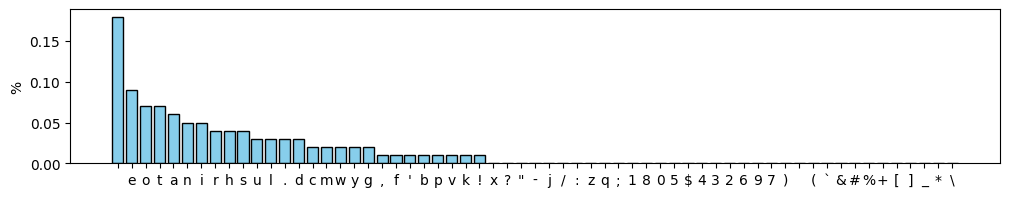

In [48]:
char_frequencies = sorted(char_frequencies, key=lambda elem: elem[1], reverse=True)

plt.figure(figsize=(12, 2))
plt.bar([item[0] for item in char_frequencies], [item[1] for item in char_frequencies], color='skyblue', edgecolor='black')
plt.ylabel("%")

Unsurprisingly, space occurs most often.

#### Finding the most frequent Words

Now we will have a look at the words used. Therefore, we utilize the library Natural Language Toolkit (NLTK), which is a big library for the analysis of text.

<div class="alert alert-block alert-success">
<b>Task:</b> Complete the function <code>filter_corpus</code>. The function should filter a predefined set of stopwords out of the corpus. Use the <code>nltk</code> library to get a set of stopwords for the english language. The function should also filter out punctuation (use <code>string.punctuation</code>). The function should return a list of tuples, where each tuple contains a token and how of often the token appears in the corpus.
</div>

In [ ]:
import nltk
from nltk.corpus import stopwords
import string
nltk.download('stopwords')


def filter_corpus(tokenized_corpus:list) -> list:
    # STUDENT CODE HERE (1 pts)

    stop_words = ...
    word_counter = ...
    word_counter_filtered = ...

    # STUDENT CODE until HERE
    return word_counter_filtered

def plot_frequencies(num_words:list):
    sum_words = sum([item[1] for item in num_words])
    num_words_sorted = sorted(num_words, reverse = True, key=lambda item: item[1])
    word_freq_sorted = [(item[0], round(item[1]/sum_words*100,2)) for item in num_words_sorted]
    top_freq_words = word_freq_sorted[:10]

    plt.figure(figsize=(12, 2))
    plt.bar([item[0] for item in top_freq_words], [item[1] for item in top_freq_words], color='skyblue', edgecolor='black')
    plt.ylabel("%")

num_words_complete_corpus = filter_corpus(tokenized_corpus_complete)
num_words_homer_corpus = filter_corpus(tokenized_homer_corpus)
num_words_marge_corpus = filter_corpus(tokenized_marge_corpus)
plot_frequencies(num_words_complete_corpus)
plot_frequencies(num_words_homer_corpus)
plot_frequencies(num_words_marge_corpus)

Marge seems to deal more with her kids (Bart and Lisa) than Homer. And she does talk a lot more to Homer (see homer and homie) than Homer is talking about marge.

We could deepen the analysis at this point and start a Named Entity Recognition (NER) analysis. It would categorize the tokens in classes like <code>Person</code>, <code>Organization</code>, <code>Country</code>, <code>City</code> etc. This would remove tokens like "get", "know", "well" which do not tell as a lot yet. However, analyzing such a large corpus would take quite some time so will leave it for now.

#### Finding the most frequent N-Grams

N-Grams are sentence snippets. Take for example the sentence "Machine Learning is awesome". A 3-gram would be "Machine Learning is". Another 3-gram is "Learning is awesome". There can be also 2-grams or 4-grams etc. In the upcoming task, we will try to find the most ocurring N-grams. 

<div class="alert alert-block alert-success">
<b>Task:</b> Complete the function <code>get_top_ngrams</code>. Use the function <code>ngram</code> of NLTK to receive the n-grams. Make it dependent on the variable <code>n</code>. Count the n-grams afterwards and return a dict. The dict receives the <code>n</code> as key and the <code>top_k</code> most common n-grams as values.
</div>

In [ ]:
from nltk.util import ngrams

def get_top_ngrams(tokenized_corpus:list, n:int, top_k=5) -> dict:
    # STUDENT CODE HERE (1 pts)

    n_grams = ...
    n_grams_freq = ...
    return ...

    # STUDENT CODE until HERE


def print_ngrams(n_gram_list, top_k=5):
    
    for dic in n_gram_list:
        for n, grams in dic.items():
            print(f"Top {top_k} {n}-grams:")
            print("---------------")
            [print(" ".join(token[0])) for token in grams]
            print("===============")


n_gram_complete_corpus = []
n_gram_homer_corpus = []
n_gram_marge_corpus =[]

for i in range(2, 10):
    n_gram_complete_corpus.append(get_top_ngrams(tokenized_corpus_complete, i))
    n_gram_homer_corpus.append(get_top_ngrams(tokenized_homer_corpus, i))
    n_gram_marge_corpus.append(get_top_ngrams(tokenized_marge_corpus, i))

In [ ]:
print("Complete Corpus\n")
print_ngrams(n_gram_complete_corpus)
print("\nHomer Corpus\n")
print_ngrams(n_gram_homer_corpus)
print("\nMarge Corpus\n")
print_ngrams(n_gram_marge_corpus)

Is it just me or do we see a little bit more gibberish in the larger n-grams of Homer compared to Marge?

#### Investigate whether speaking shares change over Episodes

Now, we would like to know, whether the speaking shares of the Simpsons family changes over time. Let's generate a line plot to get a good overview over it.

<div class="alert alert-block alert-success">
<b>Task:</b> We simply count the tokens that each character speaks per episode. Please complete the code below again. Filter our dataframe after each character, iterate over the received rows and count the words.
</div>

In [ ]:
max_episode_id = np.max(df["episode_id"])

simpson_family = ["Homer Simpson", "Marge Simpson", "Bart Simpson", "Lisa Simpson", "Maggie Simpson"]
words_spoken = {"Homer Simpson": [], "Marge Simpson": [], "Bart Simpson": [], "Lisa Simpson": [], "Maggie Simpson": []}

for episode_id in range(1,max_episode_id):
    episode = df.loc[df["episode_id"] == episode_id]

    for character in simpson_family:
        
        # STUDENT CODE HERE (2 pts)

        character_df: pd.DataFrame = ...

        # STUDENT CODE until HERE

plt.figure(figsize=(20, 5))
plt.plot(words_spoken["Homer Simpson"], label='Homer')
plt.plot(words_spoken["Marge Simpson"], label='Marge')
plt.plot(words_spoken["Bart Simpson"], label='Bart')
plt.plot(words_spoken["Lisa Simpson"], label='Lisa')
plt.plot(words_spoken["Maggie Simpson"], label='Maggie')

plt.xlabel('Episode')
plt.ylabel('Words Spoken')
plt.title('Line Plot Comparison of Multiple Lists')
plt.legend()
plt.show()

Obviously, Homer is talking the most, followed by Marge, Bart and Lisa. Maggie is in last place, lagging behind. Below you can see how often each character takes the word and talks.

In [ ]:
# Number of how often characters said someting. 
print(df[df["raw_character_text"].isin(simpson_family)]["raw_character_text"].value_counts())

### The model

Let's start with defining our model. 

<div class="alert alert-block alert-success">
<b>Task:</b> Please complete the forward pass. The input is fed first into <code>self.lstm</code>. Afterwards, we take only the last output and feed that into <code>self.dropout</code> and <code>self.linear</code>. 


<ul>
<li><b>Hint:</b> Consult the pytorch documentation to find out the output dimensions of the LSTM layer.
</ul>
</div>

In [ ]:
class CharModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=256, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        self.linear = nn.Linear(256, n_vocab)
    def forward(self, x):
        # STUDENT CODE HERE (2 pts)

        x, _ = ...
        x = ...
        x = ...

        # STUDENT CODE until HERE
        return x
    
naive_lstm = CharModel()

optimizer = optim.SGD(naive_lstm.parameters(), lr=0.001, momentum=0.9)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
loss_fn = nn.CrossEntropyLoss(reduction="sum")

### Training Loop

<div class="alert alert-block alert-success">
<b>Task 1:</b> Send inputs and labels to device. 

<b>Task 2:</b> Calculate the forward pass and the loss. 

<b>Task 3:</b> Calculate the statistics. 
</div>

In [ ]:
def train_model(model, criterion, optimizer, scheduler, dataloaders: dict, dataset_sizes: dict, num_epochs=25):
    loss_history = []
    best_loss = 0
    early_stop = False
    since = time.time()

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in tqdm(dataloaders[phase]):
                    # STUDENT CODE HERE (1 pts)

                    inputs = ...
                    labels = ...

                    # STUDENT CODE until HERE

                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):

                        # STUDENT CODE HERE (2 pts)

                        outputs = ...
                        _, preds = ...
                        loss = ...

                        # STUDENT CODE until HERE

                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    # STUDENT CODE HERE (2 pts)

                    running_loss += ...
                    running_corrects += ...

                    # STUDENT CODE until HERE

                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f}')

                # deep copy the model
                if phase == 'val' and epoch_loss > best_loss:
                    torch.save(model.state_dict(), best_model_params_path)

                # Early stopping logic
                if epoch_loss < best_loss:
                    best_loss = epoch_loss
                    loss_history = []  # Reset history since we have a new best
                else:
                    loss_history.append(epoch_loss)
                    if len(loss_history) >= 10:
                        print("Early stopping triggered!")
                        early_stop = True
                        break

            # If early stopping condition is met
            if early_stop:
                break

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path))
        torch.save(model, "models/naive_lstm")
    return model

### Training

In [ ]:
naive_lstm = naive_lstm.to(DEVICE)
# model_trained = train_model(model = naive_lstm, criterion=loss_fn, optimizer=optimizer, scheduler=exp_lr_scheduler, dataloaders= dataloaders, dataset_sizes=dataset_sizes, num_epochs=25)

In [ ]:
naive_lstm = torch.load("models/naive_lstm_best", map_location=torch.device("cpu"), weights_only=False)

### Generate Text and Evaluate with BLEU Score

We would like to evaluate how good the model performs. The accuracy measure is not feasible for this. Instead, we are going to use the Bilingual Evaluation Understudy score (BLEU). It is a metric used to evaluate the quality of text generated by a machine, particularly in the context of machine translation. It compares the machine-generated text to one or more reference texts (usually human-generated) by measuring how many n-grams (sequences of words) in the generated text appear in the reference texts.

BLEU calculates the precision of n-grams between the generated and reference texts. It considers different lengths of n-grams (e.g., unigrams, bigrams, trigrams, etc.) to ensure that the generated text matches not only in terms of word choice but also in word order and context.

For each n-gram length, BLEU calculates precision, which is the fraction of n-grams in the generated text that appear in the reference text. However, simply having high precision might not be enough, as a generated text could be overly short, leading to inflated precision scores. To address this, BLEU introduces a brevity penalty to penalize very short translations.

$$\text{BLEU} = \text{BP} \cdot \exp\left(\sum_{n=1}^{N} w_n \cdot \log p_n\right)$$

The brevity penalty (BP) ensures that shorter generated texts, which might have high precision by omitting words, are penalized. This prevents the model from generating overly short outputs that do not cover the content of the reference text. If the candidate text length $c$ is greater than the reference length $r$, BP is set to 1 (no penalty). If $c$ is less than or equal to $r$, BP decreases exponentially as the length difference increases.

$$\text{BP} = 
\begin{cases} 
1 & \text{if } c > r \\
\exp(1 - \frac{r}{c}) & \text{if } c \leq r
\end{cases}
$$

- $c$  is the length of the candidate (generated) text.
- $r$  is the length of the reference text.
- $p_n$ is the precision for n-grams of length  $n$ .
- $w_n$ is the weight for each n-gram length, typically equal for all  $n$ .


<div class="alert alert-block alert-success">
<b>Task:</b> When computing the BLEU score, especially for shorter sentences or for higher-order n-grams (like trigrams, 4-grams, etc.), there's a possibility that some n-grams in the generated text do not appear in the reference text at all. This leads to a precision of zero for that particular n-gram order, which can dramatically lower the overall BLEU score.

To avoid this, smoothing is applied. Smoothing methods adjust the precision calculations to prevent any of them from being zero. The SmoothingFunction class in nltk provides different methods for smoothing the BLEU score. 

Your task is to define this smoothing function. Use <code>method1</code>. <code>reference</code> is the next cell in the dataframe. We would like to compare the models prediction with this reference. Additionally, we need the <code>tokenized_reference</code>. It can be found in <code>df</code> as well. Last but not least, we have to adjust the <code>text_generation_len</code>, as we try to help our model a little by telling it, how long the generation has to be.

</div>

In [ ]:
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction

def generate_text(df, model, char_to_int, int_to_char, device, evaluate_bleu:bool, tokenizer, text_generation_len = 1000):

    result_complete = []
    max_id = df.index.max()
    random_id = np.random.randint(0, max_id+1)
    prompt = df.loc[df.index==random_id, "cleaned_raw_text"].values[0]
    print(f"Random prompt is: \n'{prompt}'")
    pattern = [char_to_int[c] for c in prompt]

    if evaluate_bleu:
        # STUDENT CODE HERE (2 pts)

        smooth_fn = ...
        reference = ...
        tokenized_reference = ...
        text_generation_len = ...

        # STUDENT CODE until HERE
    model.eval()
    with torch.no_grad():
        print("Model generates:")
        for i in range(text_generation_len):
            x = np.reshape(pattern, (1, len(pattern), 1)) / float(n_vocab)
            x = torch.tensor(x, dtype=torch.float32).to(device)
            prediction = model(x)
            index = int(prediction.argmax())
            result_complete.append(int_to_char[index])
            pattern.append(index)
            pattern = pattern[1:]

    result_complete = "".join(result_complete)
    print(result_complete)
    
    if evaluate_bleu:
        print(f"Referenced text is: \n{reference}")
        print(f"Bleu score is: {round(sentence_bleu(tokenized_reference, tokenizer.encode(result_complete).tokens, smoothing_function=smooth_fn), 3)}")

generate_text(df, 
              naive_lstm, 
              char_to_int=char_to_int, 
              int_to_char=int_to_char, 
              device = "cpu", 
              evaluate_bleu=True,
              tokenizer=tokenizer,
              text_generation_len=200)

The BLEU score is obviously not very good. Let's see, how our next model is doing. 

## LSTM with Word Embeddings

### Basics

So, as you have seen, simply generating text with single characters is difficult. This is because when tokenizing on word or subword level, the semantics and syntactics of the text is preserved better. Words often correspond to meaningful units. Take the word "cat" and compare it with three singualar characters "c", "a" and "t". This does make a difference. 

Therefore we tokenize our corpuses usually first. 

Unfortunately, that leads as to a new problem. While we only found 61 unique characters, which we already filtered for non-ascii symbols, numerating them would not be feasible. English Wictionary (according to Wikipedia) contains approximately 755000 headwords. Embedding them by numeration or via one-hot-encoding would not work. 

[[10]](#10) came up with the solution: The tokens are represented as vectors in a high-dimensional feature space. These representations are learned via another neural network such that tokens that are similar receive similar vectors. This approach was named Word2Vec. It has a weakness which we will have a look at later. 

We will use the library gensim to generate these vectors from our corpus. Each token receives an id. Each id points to a row in our matrix, that holds the vectors. This matrix is called embedding matrix. 

### Word2Vec

<div class="alert alert-block alert-success">
<b>Task:</b> Train a Word2Vec model. Use <code>df['tokenized_raw_text']</code>, <code>vector_size=300</code>, <code>window=5</code> and <code>min_count=1</code>

</div>

In [ ]:
from gensim.models import Word2Vec

# STUDENT CODE HERE (1 pts)

w2v_model = ...

# STUDENT CODE until HERE

A very cool thing with word vectors is, that we can conduct calculations with it. We can also measure the similarity of words. We can also transform these vectors in 2 or 3 dimensions and plot them. 

We will do all these things in the following code block. 

### Similarities

<div class="alert alert-block alert-success">
<b>Task:</b> Find the top 5 similar words of the word "homer" and print them. 
</div>

In [ ]:
from scipy.spatial.distance import cosine
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import random
import plotly.graph_objs as go
import plotly.express as px

# STUDENT CODE HERE (1 pts)

similar_words = ...

# STUDENT CODE until HERE

As all these words occure often together, they are measured to be very similar. I am not a Simpsons expert, but as far as I know, Grampa and Homer share many traits. It is likely, that both of these words occure around the same other words, which result in such a high similarity.

#### Calculations

We can add and subtract some word vectors and test, which vectors are similar to the calculated ones. A very famous example, it has nothing to do with the Simpsons, is: 

$$W2V(\text{king})-W2V(\text{man})+W2V(\text{woman}) = W2V(\text{queen})$$

Let's have a look at it in the context of the Simpsons.

<div class="alert alert-block alert-success">
<b>Task:</b> Using the embedding of "homer", try to reach as close as possible to the vector "marge".
<ul>
<li><b> Hint:</b> Use the function <code>cosine</code> to measure similarity. 
</ul>
</div>

In [ ]:
# STUDENT CODE HERE (1 pts)


# STUDENT CODE until HERE


#### Where is the Problem? 

So, this all looks fine. So what is the problem? 

The problem occurs, when homonyms like "bank" are used. Homonyms are words that look the same, but have different meanings. Short: Syntactically the same, semantically different. Other homonyms are for example "duck", "spring", "date", "letter", "watch" etc. 

Static word embeddings like word2vec, GloVe or FastText cannot deal with them. These words have the same vector, independent of the context that they are used in. You can see that in the next code block. 

This problem was not solved until 2018 [[11]](#11). Here, researchers came up with the model Embeddings from Language Models (ELMo). This is a bidirectional LSTM that generates contextualizes embeddings, which can be used in downstream tasks. With pretrained transformer-based models, this improved further. 

In the code block below, you can see our problem with static word embeddings. Both sentences, <code>sent1</code> and <code>sent2</code>, use the word "bank". They do not mean the same things, although they have the same word embeddings id. 

In [ ]:
sent1 = ["marge", "goes", "to", "the", "bank", "in", "springfield", "."]
sent2 = ["marge", "sits", "on", "a", "bank", "in", "springfield", "."]

id_sent1 = []
id_sent2 = []

for tok in sent1:
    id_sent1.append(w2v_model.wv.key_to_index[tok])

for tok in sent2:
    id_sent2.append(w2v_model.wv.key_to_index[tok])

print(id_sent1)
print(id_sent2)


### The model

To include to word vectors, also called embeddings, we need the pytorch embedding layer.

<div class="alert alert-block alert-success">
<b>Task 1:</b> Add the embedding layer to our model. Load the pretrained vectors into it, set <code>dtype=torch.float32</code> and <code>freeze=True</code>. Use the <code>nn.Embedding</code> layer.

<b>Task 2:</b> Do the forward pass again. We will again use only the last predicted element. 
</div>

In [ ]:
class LSTM_embedding(nn.Module):
    
    def __init__(self, w2v_model, tokenizer, hidden_dim, n_layers = 1):
        super(LSTM_embedding, self).__init__()
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers
        self.w2v_model = w2v_model
        self.tokenizer = tokenizer
        self.vocab_size = self.tokenizer.get_vocab_size()
        self.vector_size = self.w2v_model.vector_size
        self.weights_matrix = np.zeros((self.vocab_size, self.vector_size))
        
        # Populate the embedding matrix
        for token, idx in tokenizer.get_vocab().items():
            if token in w2v_model.wv:
                self.weights_matrix[idx] = w2v_model.wv[token]

        # STUDENT CODE HERE (1 pts)


        # STUDENT CODE until HERE
        self.lstm = nn.LSTM(input_size=self.vector_size, num_layers=n_layers, hidden_size=self.hidden_dim, bidirectional=False,batch_first=True)        
        self.Dropout = nn.Dropout(0.2)
        self.linear = nn.Linear(self.hidden_dim, self.vocab_size)

    def forward(self,x):
        # STUDENT CODE HERE (2 pts)


        # STUDENT CODE until HERE
        return x

### Creating Dataset and Dataloaders

<div class="alert alert-block alert-success">
<b>Task:</b> Complete the dataset class. We need a <code>torch.tensor</code> each, that holds the indexes from the token. The type should be <code>torch.long</code>. 
</div>

In [ ]:
class SimpsonsDataset_w2v(data.Dataset):
    def __init__(self, text, w2v_model, window_size=100):
        self.window_size = window_size
        self._text = text
        self.w2v_model = w2v_model

    def __len__(self):
        return len(self._text) - self.window_size

    def __getitem__(self, idx):
        x = self._text[idx:idx + self.window_size]
        y = self._text[idx + self.window_size]
        # STUDENT CODE HERE (2 pts)

        x = ...
        y = ...

        # STUDENT CODE until HERE
        return x, y
    

dataset_w2v = SimpsonsDataset_w2v(tokenized_corpus_complete, w2v_model)
batch_size = 256
# dataset_w2v = data.Subset(dataset_w2v, range(500))
train_w2v, val_w2v = data.random_split(dataset_w2v, [0.8, 0.2])

train_w2v_dataloader = torch.utils.data.DataLoader(train_w2v, batch_size=batch_size, shuffle=True)
val_w2v_dataloader = torch.utils.data.DataLoader(val_w2v, batch_size=batch_size, shuffle=False)

dataloaders_w2v: dict = {"train": train_w2v_dataloader, "val": val_w2v_dataloader}
dataset_w2v_sizes = {"train": len(train_w2v), "val": len(val_w2v)}

assert iter(train_w2v_dataloader).__next__()[0].shape == torch.Size([256, 100])
assert iter(train_w2v_dataloader).__next__()[1].shape == torch.Size([256])

### Training

In [ ]:
w2v_lstm = LSTM_embedding(w2v_model=w2v_model, tokenizer=tokenizer, hidden_dim=256,n_layers=2)
w2v_lstm = w2v_lstm.to(DEVICE)

optimizer = optim.SGD(w2v_lstm.parameters(), lr=0.001, momentum=0.9)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
loss_fn = nn.CrossEntropyLoss(reduction="sum")

# w2v_lstm_trained = train_model(model = w2v_lstm, criterion=loss_fn, optimizer=optimizer, scheduler=exp_lr_scheduler, dataloaders= dataloaders_w2v, dataset_sizes = dataset_w2v_sizes, num_epochs=25)

In [ ]:
w2v_lstm_trained = torch.load("models/lstm_embedding_best", map_location=torch.device("cpu"), weights_only=False)

### Generate some Text

<div class="alert alert-block alert-success">
<b>Task:</b> You have it almost! 

This time, please complete the function <code>generate_text</code>. We would like to first make a prediction, calcuate the most likely index and map it back to a key. Afterwards, make the predicted index to a tensor, shape it correctly and concatenate it to the existing indexes. Remove the first element of these indexes. It will not be used anymore (FIFO).
</div>

In [ ]:
def generate_text(df, model, w2v_model, evaluate_bleu= False, text_generation_len = 100):
    
    result_complete_tokenized = []
    max_id = df.index.max()
    random_id = np.random.randint(0, max_id+1)
    prompt_words = df.loc[df.index==random_id, "cleaned_raw_text"].to_list()[0]
    prompt_ids = df.loc[df.index==random_id, "tokenized_raw_text"].to_list()[0]
    print(f"Random prompt is:\n'{prompt_words}'")

    if evaluate_bleu:
        smooth_fn = SmoothingFunction().method1
        reference = df.loc[df.index==random_id+1, "cleaned_raw_text"].values[0]
        referenced_tokenized = df.loc[df.index==random_id+1, "tokenized_raw_text"].values[0]
        text_generation_len = len(referenced_tokenized)

    pattern = torch.tensor([w2v_model.wv.key_to_index.get(token) for token in prompt_ids], dtype=torch.long)
    pattern = np.reshape(pattern, (1, len(pattern)))
    
    model.eval()
    with torch.no_grad():
        print("Model generates: ")
        for i in range(text_generation_len):
            
            # STUDENT CODE HERE (4 pts)

            prediction = ...
            index = ...
            result = ...
            pred_index = ...
            concat_index = ...
            pattern = ...
            pattern = ...

            # STUDENT CODE until HERE

            result_complete_tokenized.append(result)

    result_complete = " ".join(result_complete_tokenized)
    print(result_complete)
    if evaluate_bleu:
        print(f"Reference test: \n{reference}")
        print(f"Bleu score is: {round(sentence_bleu(referenced_tokenized, result_complete_tokenized, smoothing_function=smooth_fn), 3)}")

generate_text(df, w2v_lstm_trained, w2v_model, evaluate_bleu=True)

### References

<a id="1">[1]</a> J. J. Hopfield, “Neural networks and physical systems with emergent collective computational abilities.,” Proceedings of the National Academy of Sciences, vol. 79, no. 8, pp. 2554–2558, Apr. 1982, doi: 10.1073/pnas.79.8.2554.

<a id="2">[2]</a> D. E. Rumelhart, G. E. Hinton, and R. J. Williams, “(1986) D. E. Rumelhart, G. E. Hinton, and R. J. Williams, Learning internal representations by error propagation, Parallel Distributed Processing: Explorations in the Microstructures of Cognition, Vol. I, D. E. Rumelhart and J. L. McClelland (Eds.) Cambridge, MA: MIT Press, pp. 318-362,” Apr. 1988, doi: 10.7551/mitpress/4943.003.0128.

<a id="3">[3]</a> R. M. Schmidt, “Recurrent Neural Networks (RNNs): A gentle Introduction and Overview.” arXiv, Nov. 23, 2019. Accessed: Jun. 13, 2024. [Online]. Available: http://arxiv.org/abs/1912.05911

<a id="4">[4]</a> S. Helmini, “All you need to know about RNNs,” Medium. Accessed: Jun. 16, 2024. [Online]. Available: https://towardsdatascience.com/all-you-need-to-know-about-rnns-e514f0b00c7c

<a id="5">[5]</a> S. Hochreiter and J. Schmidhuber, “Long Short-Term Memory,” Neural Computation, vol. 9, no. 8, pp. 1735–1780, Nov. 1997, doi: 10.1162/neco.1997.9.8.1735.

<a id="6">[6]</a> “CS 230 - Recurrent Neural Networks Cheatsheet.” Accessed: Jun. 18, 2024. [Online]. Available: https://stanford.edu/~shervine/teaching/cs-230/cheatsheet-recurrent-neural-networks

<a id="7">[7]</a> R. T. J. J, “LSTMs Explained: A Complete, Technically Accurate, Conceptual Guide with Keras,” Analytics Vidhya. Accessed: Jun. 18, 2024. [Online]. Available: https://medium.com/analytics-vidhya/lstms-explained-a-complete-technically-accurate-conceptual-guide-with-keras-2a650327e8f2

<a id="8">[8]</a> DNK, “What is the intuition of using tanh in LSTM?,” Stack Overflow. Accessed: Jun. 19, 2024. [Online]. Available: https://stackoverflow.com/q/40761185

<a id="9">[9]</a> Image Simpson Family, PNGWING, URL: https://www.pngwing.com/en/free-png-ziauf, Accessed: 16.08.2024

<a id="10">[10]</a> T. Mikolov, K. Chen, G. Corrado, and J. Dean, “Efficient Estimation of Word Representations in Vector Space,” Sep. 06, 2013, arXiv: arXiv:1301.3781. doi: 10.48550/arXiv.1301.3781.

<a id="11">[11]</a> M. E. Peters et al., “Deep contextualized word representations,” Mar. 22, 2018, arXiv: arXiv:1802.05365. doi: 10.48550/arXiv.1802.05365.

